# Quantum Teleportation Part A


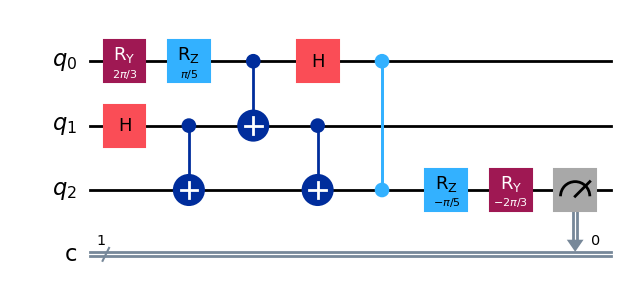

Measurement results (5000 shots):
{'0': 5000}


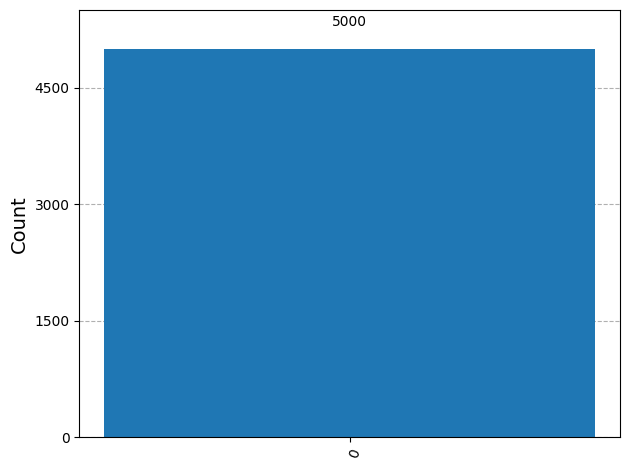

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np

qc = QuantumCircuit(3,1)

theta = 2*(np.pi)/3 
phi = (np.pi)/5


#Applying angles
qc.ry(theta,0)
qc.rz(phi,0)


#creating of Bell States
qc.h(1)
qc.cx(1,2)


qc.cx(0,1)
qc.h(0)


qc.cx(1, 2) 
qc.cz(0, 2) 


#reversing the state 

qc.rz(-phi,2)
qc.ry(-theta,2)

qc.measure(2,0)

display(qc.draw("mpl"))

sim = AerSimulator()
result = sim.run(qc, shots=5000).result()
counts = result.get_counts()
print("Measurement results (5000 shots):")
print(counts)
plot_histogram(counts)

# TELEPORTATION PART B ANSWERS

# 1. What do you observe in the histogram after applying U†?

After applying the inverse unitary operation U† on Bob’s qubit and running the circuit for 5000 shots, the measurement outcome shows that Bob measures the state |0⟩ with 100% probability.

This indicates that Bob’s qubit has successfully reconstructed the original quantum state |ψ⟩ that was prepared by Alice. Since the measurement result is always |0⟩ after applying U†, it confirms that the teleportation process worked correctly and the unknown quantum state was transferred perfectly from Alice to Bob.

Thus, the histogram verifies the successful implementation of quantum teleportation.


# 2. Why does applying U† verify teleportation?

Alice initially prepares an unknown quantum state as:

|ψ⟩ = U|0⟩

If teleportation is successful, Bob’s qubit becomes |ψ⟩. To verify this, we apply the inverse unitary operation U† to Bob’s qubit:

U†|ψ⟩ = U†U|0⟩ = I|0⟩ = |0⟩

Since U†U equals the identity operator, the state returns to |0⟩. Therefore, if measuring Bob’s qubit after applying U† always gives |0⟩, it confirms that Bob correctly received the state |ψ⟩ and teleportation was successful.

Hence, applying U† acts as a verification step for correct teleportation.


# 3. Why were classical bits not required in this assignment?

In the standard quantum teleportation protocol, Alice measures her qubits and sends two classical bits to Bob. Based on those classical bits, Bob applies conditional correction gates (X and Z) to recover the original state.

However, in this assignment, measurements and classical communication were avoided. Instead, quantum controlled gates (CX and CZ) were used to perform the correction coherently in superposition. These gates automatically apply the necessary correction to Bob’s qubit without collapsing the quantum state.

As a result, the entire teleportation process remains fully unitary and does not require classical communication. This approach is known as fully quantum or coherent teleportation, where corrections are applied using entanglement and controlled operations instead of classical bits.

# Superdense Coding (Bell State) Part A

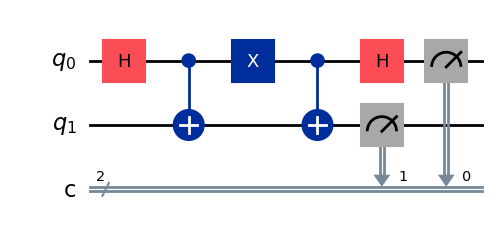

Measurement results (1 shot):
{'10': 1}


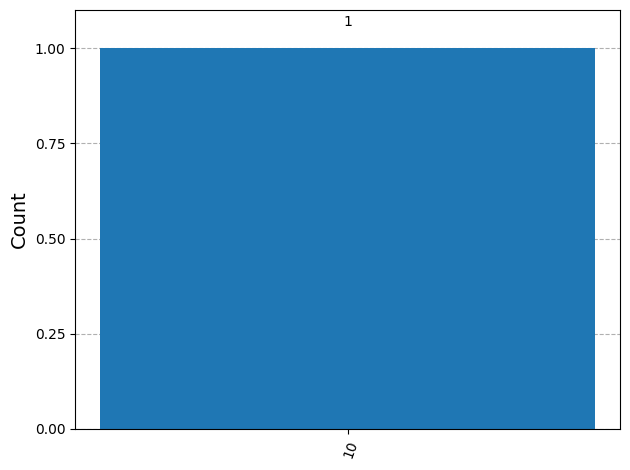

In [2]:
qc = QuantumCircuit(2,2)

#creating of Bell States
qc.h(0)
qc.cx(0,1)

qc.x(0)
#qc.z(0)


qc.cx(0,1)
qc.h(0)

qc.measure([0,1],[0,1]) # the bits are flipped due to Endianness 

display(qc.draw("mpl"))

sim = AerSimulator()
result = sim.run(qc, shots=1).result()
counts = result.get_counts()
print("Measurement results (1 shot):")
print(counts)
plot_histogram(counts)


# SUPERDENSE CODING PART B ANSWERS

# 1. What happens if an eavesdropper intercepts the qubit sent from Alice to Bob?

If an eavesdropper intercepts the qubit sent from Alice to Bob, they cannot extract the encoded classical information. This is because the information is not contained in the single qubit alone but is encoded in the shared entangled Bell state between Alice and Bob.

Without access to Bob’s entangled qubit, the intercepted qubit appears as a completely random quantum state. Any measurement performed by the eavesdropper will yield random results and will also disturb the quantum state due to the collapse of superposition. This disturbance can be detected by Alice and Bob, revealing the presence of an eavesdropper.

Thus, superdense coding provides inherent security because the transmitted qubit alone does not reveal the encoded message.


# 2. Give one application or implication of superdense coding.

One important application of superdense coding is efficient quantum communication, where two classical bits of information can be transmitted using only one qubit with the help of shared entanglement. This increases communication capacity beyond classical limits.

Superdense coding is also significant in the development of quantum communication networks and the quantum internet, where it enables faster and more secure data transmission. It demonstrates how entanglement can be used as a resource to enhance communication efficiency and plays a key role in advanced quantum communication protocols.